# 의사결정나무 회귀 분석
## 한국철도공사 카드 소비액 예측 모델

### 목표
- 지역(시도, 시군구), 시간대, 소비업종 데이터를 기반으로
- **전체_카드** (총 카드 소비액)을 예측하는 회귀 모델 구축
- 의사결정나무(DecisionTreeRegressor)를 사용

### 프로세스
1. 데이터 로드 및 탐색
2. 데이터 전처리 (인코딩, 분할)
3. 의사결정나무 회귀 모델 학습
4. 성능 평가 (RMSE, MAE, R²)
5. 결과 시각화

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
from matplotlib import rc

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    rc('font', family='Malgun Gothic')

from IPython.display import Image

np.set_printoptions(suppress=True, precision=4)
pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.rcParams['font.size'] = 14

random_seed = 123

# 머신러닝 라이브러리 import
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1단계: 데이터 로드 및 탐색

In [2]:
# CSV 파일 읽기
df = pd.read_csv('input/한국철도공사_시군구단위 거주 철도이용객 이용 시간대별 소비업종 정보_20221115.csv')

print("="*70)
print("[1-1] 데이터 기본 정보")
print("="*70)
print(f"데이터 크기: {df.shape[0]:,}행 x {df.shape[1]}열")
print(f"\n컬럼 목록:")
for i, col in enumerate(df.columns):
    print(f"  {i:2d}. {col}")

print(f"\n\n결측치 확인:")
null_sum = df.isnull().sum().sum()
print(f"  총 결측치: {null_sum}개" if null_sum > 0 else "  결측치 없음 ✓")

print(f"\n\n기본 통계:")
print(df.describe())

[1-1] 데이터 기본 정보
데이터 크기: 1,250행 x 18열

컬럼 목록:
   0. 법정동시도코드
   1. 시도명
   2. 법정동시군구코드
   3. 시군구명
   4. 시간코드
   5. 전체_카드
   6. 교통
   7. 백화점
   8. 소형유통
   9. 숙박
  10. 스포츠외
  11. 여행
  12. 요식
  13. 의료
  14. 주유
  15. 주차장
  16. 편의점
  17. 할인점외


결측치 확인:
  결측치 없음 ✓


기본 통계:
         법정동시도코드   법정동시군구코드       시간코드       전체_카드          교통         백화점  \
count 1,250.0000 1,250.0000 1,250.0000  1,250.0000  1,250.0000  1,250.0000   
mean     37.7120   436.1440    53.0000 10,804.3176  3,663.9568  1,621.1408   
std      11.2503   281.8709     1.4148 13,390.7307  4,517.1796  2,226.2043   
min      11.0000   110.0000    51.0000     30.0000      0.0000      0.0000   
25%      29.0000   170.0000    52.0000    930.2500    285.5000     96.0000   
50%      42.0000   315.0000    53.0000  5,305.5000  1,847.0000    676.0000   
75%      46.0000   740.0000    54.0000 16,678.7500  5,578.0000  2,187.5000   
max      50.0000   940.0000    55.0000 77,802.0000 26,290.0000 13,125.0000   

             소형유통         숙박    

## 2단계: 데이터 전처리

In [3]:
# 데이터 복사
df_ml = df.copy()

print("="*70)
print("[2-1] 특징(Feature)과 목표(Target) 분리")
print("="*70)

# 목표변수: 전체_카드
y = df_ml['전체_카드']

# 특징: 지역(시도, 시군구), 시간대, 소비업종
# 불필요한 컬럼 제거: 코드 컬럼은 숫자지만 의미적으로 카테고리이므로 명시 제거
feature_cols = [col for col in df_ml.columns 
                if col not in ['전체_카드', '법정동시도코드', '법정동시군구코드']]

X = df_ml[feature_cols]

print(f"목표변수 (y): 전체_카드")
print(f"  - 형태: {y.shape}")
print(f"  - 통계: mean={y.mean():.0f}, std={y.std():.0f}, min={y.min():.0f}, max={y.max():.0f}")

print(f"\n특징변수 (X): {X.shape[1]}개 컬럼")
print(f"  {feature_cols}")

print(f"\n\n데이터 타입:")
print(X.dtypes)

[2-1] 특징(Feature)과 목표(Target) 분리
목표변수 (y): 전체_카드
  - 형태: (1250,)
  - 통계: mean=10804, std=13391, min=30, max=77802

특징변수 (X): 15개 컬럼
  ['시도명', '시군구명', '시간코드', '교통', '백화점', '소형유통', '숙박', '스포츠외', '여행', '요식', '의료', '주유', '주차장', '편의점', '할인점외']


데이터 타입:
시도명       str
시군구명      str
시간코드    int64
교통      int64
백화점     int64
소형유통    int64
숙박      int64
스포츠외    int64
여행      int64
요식      int64
의료      int64
주유      int64
주차장     int64
편의점     int64
할인점외    int64
dtype: object


In [4]:
print("="*70)
print("[2-2] 범주형 특징 인코딩 (LabelEncoder)")
print("="*70)

# 범주형 컬럼 찾기
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"범주형 컬럼 ({len(categorical_cols)}개): {categorical_cols}")
print(f"수치형 컬럼 ({len(numeric_cols)}개): {numeric_cols}")

# LabelEncoder로 범주형 컬럼 변환
le_dict = {}  # 인코더 저장
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    le_dict[col] = le
    print(f"\n{col}: {len(le.classes_)}개 클래스")
    if len(le.classes_) <= 20:
        for i, cls in enumerate(le.classes_):
            print(f"    {i} → {cls}")

print(f"\n\n인코딩 후 X_encoded:")
print(X_encoded.head())

[2-2] 범주형 특징 인코딩 (LabelEncoder)
범주형 컬럼 (2개): ['시도명', '시군구명']
수치형 컬럼 (13개): ['시간코드', '교통', '백화점', '소형유통', '숙박', '스포츠외', '여행', '요식', '의료', '주유', '주차장', '편의점', '할인점외']

시도명: 17개 클래스
    0 → 강원
    1 → 경기
    2 → 경남
    3 → 경북
    4 → 광주
    5 → 대구
    6 → 대전
    7 → 부산
    8 → 서울
    9 → 세종
    10 → 울산
    11 → 인천
    12 → 전남
    13 → 전북
    14 → 제주
    15 → 충남
    16 → 충북

시군구명: 228개 클래스


인코딩 후 X_encoded:
   시도명  시군구명  시간코드    교통   백화점   소형유통    숙박  스포츠외   여행     요식    의료    주유  \
0    1    16    51  8255  3771  13045  1269  4797  495  33636  1787  7532   
1   12   225    52   338   115    496    39   143    9   1122    60   307   
2    8     1    51  9415  4731   9066  1793  5008  436  29240  1445  5064   
3    1     0    55   435   132    415    45   160    6   1062    35   288   
4   16   203    55   789   170    681    85   251    7   1866    57   517   

    주차장    편의점   할인점외  
0  3162  14106  13326  
1   104    454    417  
2  2782  12480  10499  
3    67    458    328  
4   149  

In [5]:
print("="*70)
print("[2-3] 데이터 분할 (Train/Test Split)")
print("="*70)

# Train/Test 분할 (7:3 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=random_seed
)

print(f"Train 데이터: {X_train.shape[0]:,}개 ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Test 데이터:  {X_test.shape[0]:,}개 ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")

print(f"\nTrain 목표변수 통계:")
print(f"  mean: {y_train.mean():.0f}, std: {y_train.std():.0f}")

print(f"\nTest 목표변수 통계:")
print(f"  mean: {y_test.mean():.0f}, std: {y_test.std():.0f}")

[2-3] 데이터 분할 (Train/Test Split)
Train 데이터: 875개 (70.0%)
Test 데이터:  375개 (30.0%)

Train 목표변수 통계:
  mean: 10955, std: 13609

Test 목표변수 통계:
  mean: 10452, std: 12877


## 3단계: 의사결정나무 회귀 모델 학습

In [6]:
print("="*70)
print("[3-1] 의사결정나무 회귀 - 기본 모델")
print("="*70)

# 의사결정나무 회귀 모델 생성 및 학습
dt_regressor = DecisionTreeRegressor(
    random_state=random_seed,
    max_depth=10,  # 과적합 방지
    min_samples_split=10,
    min_samples_leaf=5
)

dt_regressor.fit(X_train, y_train)

print(f"모델 학습 완료")
print(f"\n모델 파라미터:")
print(f"  - max_depth: {dt_regressor.max_depth}")
print(f"  - min_samples_split: {dt_regressor.min_samples_split}")
print(f"  - min_samples_leaf: {dt_regressor.min_samples_leaf}")
print(f"  - 실제 트리 깊이: {dt_regressor.get_depth()}")
print(f"  - 리프 노드 수: {dt_regressor.get_n_leaves()}")

[3-1] 의사결정나무 회귀 - 기본 모델
모델 학습 완료

모델 파라미터:
  - max_depth: 10
  - min_samples_split: 10
  - min_samples_leaf: 5
  - 실제 트리 깊이: 10
  - 리프 노드 수: 136


## 4단계: 성능 평가

In [7]:
print("="*70)
print("[4-1] Train/Test 예측 및 성능 지표")
print("="*70)

# Train 데이터에 대한 예측
y_train_pred = dt_regressor.predict(X_train)

# Test 데이터에 대한 예측
y_test_pred = dt_regressor.predict(X_test)

print("\n[Train 데이터 성능]")
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print(f"  MAE (평균절대오차):  {train_mae:>10,.0f}원")
print(f"  RMSE (제곱근오차):   {train_rmse:>10,.0f}원")
print(f"  R² 점수:             {train_r2:>10.4f}")

print("\n[Test 데이터 성능]")
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"  MAE (평균절대오차):  {test_mae:>10,.0f}원")
print(f"  RMSE (제곱근오차):   {test_rmse:>10,.0f}원")
print(f"  R² 점수:             {test_r2:>10.4f}")

print("\n[과적합 분석]")
print(f"  Train R² - Test R²: {train_r2 - test_r2:.4f}")
if train_r2 - test_r2 > 0.1:
    print(f"  → 과적합 경향 있음 (Train과 Test 성능 차이 큼)")
else:
    print(f"  → 적절한 수준의 모델 성능")

[4-1] Train/Test 예측 및 성능 지표

[Train 데이터 성능]
  MAE (평균절대오차):         261원
  RMSE (제곱근오차):          647원
  R² 점수:                 0.9977

[Test 데이터 성능]
  MAE (평균절대오차):         451원
  RMSE (제곱근오차):          903원
  R² 점수:                 0.9951

[과적합 분석]
  Train R² - Test R²: 0.0027
  → 적절한 수준의 모델 성능


In [8]:
print("="*70)
print("[4-2] 교차검증 (Cross Validation)")
print("="*70)

# 5-fold 교차검증
cv_scores = cross_val_score(
    dt_regressor, X_encoded, y,
    cv=5,  # 5-fold
    scoring='r2'  # R² 점수 사용
)

print(f"\n5-Fold 교차검증 결과:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\n  평균 R² 점수: {cv_scores.mean():.4f}")
print(f"  표준편차:     {cv_scores.std():.4f}")

[4-2] 교차검증 (Cross Validation)

5-Fold 교차검증 결과:
  Fold 1: 0.9937
  Fold 2: 0.9947
  Fold 3: 0.9948
  Fold 4: 0.9958
  Fold 5: 0.9886

  평균 R² 점수: 0.9935
  표준편차:     0.0025


## 5단계: 특징 중요도 분석

In [9]:
print("="*70)
print("[5-1] 특징 중요도 (Feature Importance)")
print("="*70)

# 특징 중요도
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': dt_regressor.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n총 {len(feature_importance)}개 특징의 중요도:")
for idx, row in feature_importance.iterrows():
    pct = row['Importance'] * 100
    bar = '█' * int(pct / 2)  # 시각적 바
    print(f"  {row['Feature']:15s}: {pct:6.2f}% {bar}")

print(f"\n\nTop 5 중요 특징:")
for i, (idx, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importance']*100:.2f}%")

[5-1] 특징 중요도 (Feature Importance)

총 15개 특징의 중요도:
  할인점외           :  95.79% ███████████████████████████████████████████████
  소형유통           :   2.71% █
  요식             :   1.29% 
  주차장            :   0.06% 
  주유             :   0.05% 
  시도명            :   0.03% 
  교통             :   0.03% 
  편의점            :   0.02% 
  시군구명           :   0.01% 
  백화점            :   0.01% 
  시간코드           :   0.00% 
  숙박             :   0.00% 
  의료             :   0.00% 
  여행             :   0.00% 
  스포츠외           :   0.00% 


Top 5 중요 특징:
  1. 할인점외: 95.79%
  2. 소형유통: 2.71%
  3. 요식: 1.29%
  4. 주차장: 0.06%
  5. 주유: 0.05%


## 6단계: 결과 시각화

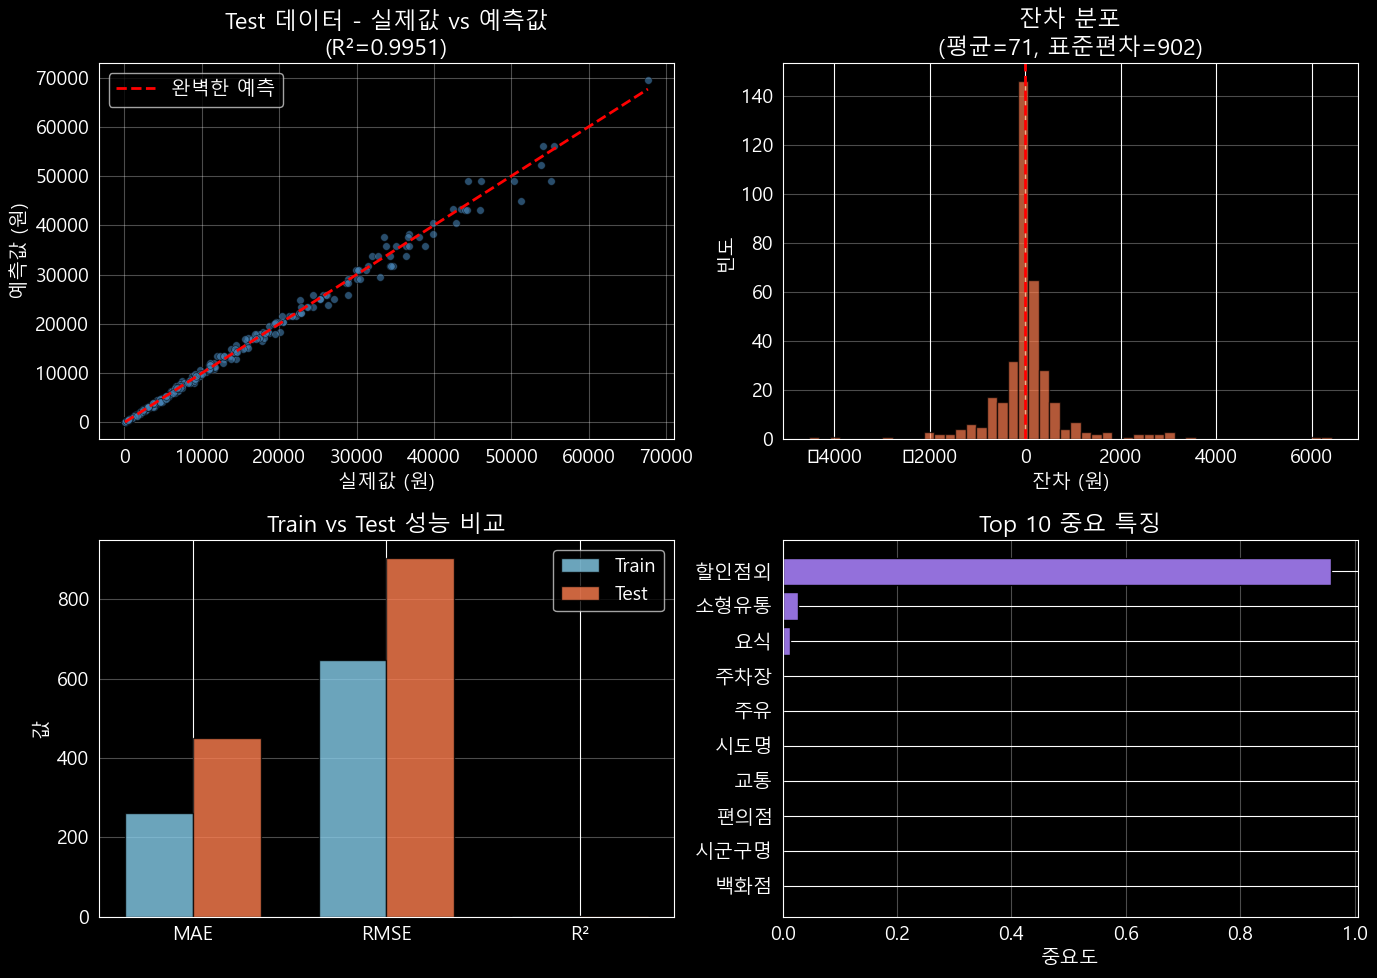

그래프 저장 완료: output/02_의사결정나무_회귀분석.png


In [10]:
# 시각화 1: 실제값 vs 예측값 (Test)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Test 데이터 산점도
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.6, s=30, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='완벽한 예측')
axes[0, 0].set_xlabel('실제값 (원)')
axes[0, 0].set_ylabel('예측값 (원)')
axes[0, 0].set_title(f'Test 데이터 - 실제값 vs 예측값\n(R²={test_r2:.4f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 잔차 분포
residuals = y_test - y_test_pred
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('잔차 (원)')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].set_title(f'잔차 분포\n(평균={residuals.mean():.0f}, 표준편차={residuals.std():.0f})')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Train vs Test 성능 비교
metrics = ['MAE', 'RMSE', 'R²']
train_values = [train_mae, train_rmse, train_r2 * 10000]  # R²는 스케일을 맞추기 위해 곱함
test_values = [test_mae, test_rmse, test_r2 * 10000]

x = np.arange(len(metrics))
width = 0.35
axes[1, 0].bar(x - width/2, [train_mae, train_rmse, train_r2], width, label='Train', alpha=0.8, color='skyblue', edgecolor='black')
axes[1, 0].bar(x + width/2, [test_mae, test_rmse, test_r2], width, label='Test', alpha=0.8, color='coral', edgecolor='black')
axes[1, 0].set_ylabel('값')
axes[1, 0].set_title('Train vs Test 성능 비교')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. 특징 중요도 (Top 10)
top_features = feature_importance.head(10)
axes[1, 1].barh(range(len(top_features)), top_features['Importance'].values, color='mediumpurple', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_features)))
axes[1, 1].set_yticklabels(top_features['Feature'].values)
axes[1, 1].set_xlabel('중요도')
axes[1, 1].set_title('Top 10 중요 특징')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('output/02_의사결정나무_회귀분석.png', dpi=100, bbox_inches='tight')
plt.show()

print("그래프 저장 완료: output/02_의사결정나무_회귀분석.png")

## 7단계: 모델 하이퍼파라미터 튜닝

[6] 하이퍼파라미터 튜닝 - 최적 max_depth 찾기

최적 max_depth: 12
최적 모델의 Test R²: 0.9951


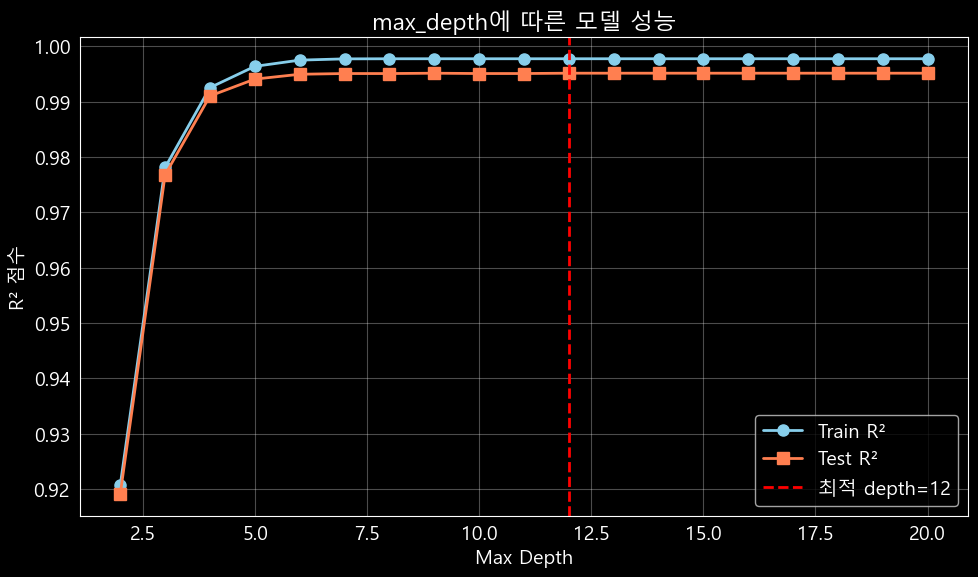


그래프 저장 완료: output/03_하이퍼파라미터튜닝.png


In [11]:
print("="*70)
print("[6] 하이퍼파라미터 튜닝 - 최적 max_depth 찾기")
print("="*70)

# 여러 max_depth 값으로 모델 성능 비교
max_depths = range(2, 21)
train_scores = []
test_scores = []

for depth in max_depths:
    dt = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=random_seed
    )
    dt.fit(X_train, y_train)
    
    train_scores.append(r2_score(y_train, dt.predict(X_train)))
    test_scores.append(r2_score(y_test, dt.predict(X_test)))

# 최적 depth 찾기
best_depth = max_depths[test_scores.index(max(test_scores))]
best_test_score = max(test_scores)

print(f"\n최적 max_depth: {best_depth}")
print(f"최적 모델의 Test R²: {best_test_score:.4f}")

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, 'o-', label='Train R²', linewidth=2, markersize=8, color='skyblue')
plt.plot(max_depths, test_scores, 's-', label='Test R²', linewidth=2, markersize=8, color='coral')
plt.axvline(x=best_depth, color='red', linestyle='--', linewidth=2, label=f'최적 depth={best_depth}')
plt.xlabel('Max Depth')
plt.ylabel('R² 점수')
plt.title('max_depth에 따른 모델 성능')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/03_하이퍼파라미터튜닝.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n그래프 저장 완료: output/03_하이퍼파라미터튜닝.png")

## 8단계: 최종 요약

In [12]:
print("="*70)
print("[7] 최종 모델 성능 요약")
print("="*70)

print(f"\n📊 의사결정나무 회귀 모델 성능")
print(f"\n[Test 데이터 기준]")
print(f"  R² 점수:           {test_r2:.4f} (설명력: {test_r2*100:.2f}%)")
print(f"  MAE (평균절대오차): {test_mae:,.0f}원")
print(f"  RMSE (제곱근오차):  {test_rmse:,.0f}원")
print(f"  실제값 평균:       {y_test.mean():,.0f}원")
print(f"  오차율(RMSE/평균): {(test_rmse/y_test.mean())*100:.2f}%")

print(f"\n[모델 구조]")
print(f"  트리 깊이:         {dt_regressor.get_depth()}")
print(f"  리프 노드 수:      {dt_regressor.get_n_leaves()}")
print(f"  총 노드 수:        {dt_regressor.tree_.node_count}")

print(f"\n[Top 3 중요 특징]")
for i, (idx, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    print(f"  {i}. {row['Feature']:15s}: {row['Importance']*100:6.2f}%")

print(f"\n[교차검증]")
print(f"  평균 R²:           {cv_scores.mean():.4f}")
print(f"  표준편차:          {cv_scores.std():.4f}")

print("\n" + "="*70)
print("✓ 의사결정나무 회귀 분석 완료")
print("="*70)

[7] 최종 모델 성능 요약

📊 의사결정나무 회귀 모델 성능

[Test 데이터 기준]
  R² 점수:           0.9951 (설명력: 99.51%)
  MAE (평균절대오차): 451원
  RMSE (제곱근오차):  903원
  실제값 평균:       10,452원
  오차율(RMSE/평균): 8.64%

[모델 구조]
  트리 깊이:         10
  리프 노드 수:      136
  총 노드 수:        271

[Top 3 중요 특징]
  1. 할인점외           :  95.79%
  2. 소형유통           :   2.71%
  3. 요식             :   1.29%

[교차검증]
  평균 R²:           0.9935
  표준편차:          0.0025

✓ 의사결정나무 회귀 분석 완료


In [13]:
# 분류 분석을 위한 추가 라이브러리 import
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

print("분류 분석 라이브러리 import 완료")

분류 분석 라이브러리 import 완료


# 의사결정나무 분류 분석
## 고소비 지역 분류 모델

### 목표
- 회귀 분석에서 예측한 **전체_카드**를 기반으로
- 지역을 **고소비/중간소비/저소비** 3개 카테고리로 분류
- 의사결정나무(DecisionTreeClassifier)를 사용

### 프로세스
1. 분류 목표변수 생성 (전체_카드 → 3분위 기반 분류)
2. 데이터 전처리 (회귀에서 사용한 X_encoded, 인코딩된 특징 재사용)
3. 의사결정나무 분류 모델 학습
4. 성능 평가 (정확도, 혼동행렬, 정밀도/재현율)
5. 결과 시각화

In [14]:
## 1단계: 분류 목표변수 생성

In [15]:
print("="*70)
print("[B-1] 분류 목표변수 생성")
print("="*70)

# 전체_카드의 3분위(33%, 67%)를 기준으로 분류
# 저소비: 33% 이하
# 중간소비: 33% ~ 67%
# 고소비: 67% 이상

q33 = y.quantile(0.33)
q67 = y.quantile(0.67)

print(f"\n3분위 분할점:")
print(f"  33 percentile: {q33:,.0f}원")
print(f"  67 percentile: {q67:,.0f}원")

# 분류 목표변수 생성
y_classified = pd.cut(y, bins=[0, q33, q67, float('inf')],
                      labels=['저소비', '중간소비', '고소비'])

print(f"\n분류 결과:")
print(f"  저소비:  {(y_classified == '저소비').sum():4d}개 ({(y_classified == '저소비').sum()/len(y)*100:5.1f}%)")
print(f"  중간소비: {(y_classified == '중간소비').sum():4d}개 ({(y_classified == '중간소비').sum()/len(y)*100:5.1f}%)")
print(f"  고소비:  {(y_classified == '고소비').sum():4d}개 ({(y_classified == '고소비').sum()/len(y)*100:5.1f}%)")

# 분류된 데이터를 숫자로 변환 (저소비=0, 중간소비=1, 고소비=2)
y_class_encoded = pd.factorize(y_classified)[0]

print(f"\n분류 목표변수 분포:")
print(y_classified.value_counts().sort_index())

[B-1] 분류 목표변수 생성

3분위 분할점:
  33 percentile: 1,638원
  67 percentile: 11,875원

분류 결과:
  저소비:   413개 ( 33.0%)
  중간소비:  424개 ( 33.9%)
  고소비:   413개 ( 33.0%)

분류 목표변수 분포:
전체_카드
저소비     413
중간소비    424
고소비     413
Name: count, dtype: int64


In [16]:
## 2단계: 분류 모델 학습

In [17]:
print("="*70)
print("[B-2] Train/Test 분할 및 분류 모델 학습")
print("="*70)

# Train/Test 분할 (회귀 분석과 동일한 비율 및 random_state 사용)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_encoded, y_class_encoded, test_size=0.3, random_state=random_seed
)

print(f"\nTrain 데이터: {X_train_c.shape[0]:,}개 ({X_train_c.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Test 데이터:  {X_test_c.shape[0]:,}개 ({X_test_c.shape[0]/len(X_encoded)*100:.1f}%)")

print(f"\nTrain 클래스 분포:")
train_counts = pd.Series(y_train_c).value_counts().sort_index()
for label in [0, 1, 2]:
    class_name = ['저소비', '중간소비', '고소비'][label]
    count = train_counts.get(label, 0)
    print(f"  {class_name}: {count:4d}개 ({count/len(y_train_c)*100:5.1f}%)")

print(f"\nTest 클래스 분포:")
test_counts = pd.Series(y_test_c).value_counts().sort_index()
for label in [0, 1, 2]:
    class_name = ['저소비', '중간소비', '고소비'][label]
    count = test_counts.get(label, 0)
    print(f"  {class_name}: {count:4d}개 ({count/len(y_test_c)*100:5.1f}%)")

# 의사결정나무 분류 모델 생성 및 학습
dt_classifier = DecisionTreeClassifier(
    random_state=random_seed,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

dt_classifier.fit(X_train_c, y_train_c)

print(f"\n✓ 의사결정나무 분류 모델 학습 완료")
print(f"  - 실제 트리 깊이: {dt_classifier.get_depth()}")
print(f"  - 리프 노드 수: {dt_classifier.get_n_leaves()}")

[B-2] Train/Test 분할 및 분류 모델 학습

Train 데이터: 875개 (70.0%)
Test 데이터:  375개 (30.0%)

Train 클래스 분포:
  저소비:  296개 ( 33.8%)
  중간소비:  286개 ( 32.7%)
  고소비:  293개 ( 33.5%)

Test 클래스 분포:
  저소비:  117개 ( 31.2%)
  중간소비:  127개 ( 33.9%)
  고소비:  131개 ( 34.9%)

✓ 의사결정나무 분류 모델 학습 완료
  - 실제 트리 깊이: 4
  - 리프 노드 수: 7


In [18]:
## 3단계: 분류 모델 성능 평가

In [19]:
print("="*70)
print("[B-3] 분류 모델 성능 평가")
print("="*70)

# Train/Test 예측
y_train_pred_c = dt_classifier.predict(X_train_c)
y_test_pred_c = dt_classifier.predict(X_test_c)

# 정확도 계산
train_accuracy = accuracy_score(y_train_c, y_train_pred_c)
test_accuracy = accuracy_score(y_test_c, y_test_pred_c)

print(f"\n[정확도 (Accuracy)]")
print(f"  Train: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Test:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  차이:  {abs(train_accuracy - test_accuracy):.4f}")

# 혼동행렬 (Confusion Matrix)
print(f"\n[Test 데이터 혼동행렬]")
cm = confusion_matrix(y_test_c, y_test_pred_c)
print(cm)
print(f"\n행렬 설명:")
print(f"  행(실제값) / 열(예측값)")
print(f"  행/열 순서: 저소비(0), 중간소비(1), 고소비(2)")

# 분류 보고서 (Classification Report)
print(f"\n[분류 성능 상세 보고서]")
class_names = ['저소비', '중간소비', '고소비']
report = classification_report(y_test_c, y_test_pred_c,
                              target_names=class_names,
                              digits=4)
print(report)

# 교차검증
cv_scores_c = cross_val_score(
    dt_classifier, X_encoded, y_class_encoded,
    cv=5,
    scoring='accuracy'
)

print(f"\n[5-Fold 교차검증]")
for i, score in enumerate(cv_scores_c, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  평균:   {cv_scores_c.mean():.4f}")
print(f"  표준편차: {cv_scores_c.std():.4f}")

[B-3] 분류 모델 성능 평가

[정확도 (Accuracy)]
  Train: 0.9931 (99.31%)
  Test:  0.9947 (99.47%)
  차이:  0.0015

[Test 데이터 혼동행렬]
[[117   0   0]
 [  0 127   0]
 [  2   0 129]]

행렬 설명:
  행(실제값) / 열(예측값)
  행/열 순서: 저소비(0), 중간소비(1), 고소비(2)

[분류 성능 상세 보고서]
              precision    recall  f1-score   support

         저소비     0.9832    1.0000    0.9915       117
        중간소비     1.0000    1.0000    1.0000       127
         고소비     1.0000    0.9847    0.9923       131

    accuracy                         0.9947       375
   macro avg     0.9944    0.9949    0.9946       375
weighted avg     0.9948    0.9947    0.9947       375


[5-Fold 교차검증]
  Fold 1: 0.9840
  Fold 2: 0.9920
  Fold 3: 0.9920
  Fold 4: 0.9880
  Fold 5: 0.9840
  평균:   0.9880
  표준편차: 0.0036


In [20]:
## 4단계: 특징 중요도 분석

In [21]:
print("="*70)
print("[B-4] 분류 모델 특징 중요도")
print("="*70)

# 특징 중요도 (분류 모델)
feature_importance_c = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n총 {len(feature_importance_c)}개 특징의 중요도:")
for idx, row in feature_importance_c.iterrows():
    pct = row['Importance'] * 100
    bar = '█' * int(pct / 2)
    print(f"  {row['Feature']:15s}: {pct:6.2f}% {bar}")

print(f"\n\nTop 5 중요 특징:")
for i, (idx, row) in enumerate(feature_importance_c.head(5).iterrows(), 1):
    print(f"  {i}. {row['Feature']:15s}: {row['Importance']*100:6.2f}%")

print(f"\n[회귀 vs 분류 - 특징 중요도 비교]")
compare_importance = pd.DataFrame({
    'Feature': feature_importance['Feature'],
    '회귀 중요도': feature_importance['Importance'].values,
    '분류 중요도': feature_importance_c.set_index('Feature').loc[feature_importance['Feature'], 'Importance'].values
})
compare_importance = compare_importance.sort_values('회귀 중요도', ascending=False).head(5)
print(compare_importance.to_string())

[B-4] 분류 모델 특징 중요도

총 15개 특징의 중요도:
  할인점외           :  99.37% █████████████████████████████████████████████████
  소형유통           :   0.34% 
  백화점            :   0.22% 
  요식             :   0.07% 
  시군구명           :   0.00% 
  시간코드           :   0.00% 
  시도명            :   0.00% 
  숙박             :   0.00% 
  교통             :   0.00% 
  여행             :   0.00% 
  스포츠외           :   0.00% 
  의료             :   0.00% 
  주유             :   0.00% 
  주차장            :   0.00% 
  편의점            :   0.00% 


Top 5 중요 특징:
  1. 할인점외           :  99.37%
  2. 소형유통           :   0.34%
  3. 백화점            :   0.22%
  4. 요식             :   0.07%
  5. 시군구명           :   0.00%

[회귀 vs 분류 - 특징 중요도 비교]
   Feature  회귀 중요도  분류 중요도
14    할인점외  0.9579  0.9937
5     소형유통  0.0271  0.0034
9       요식  0.0129  0.0007
12     주차장  0.0006  0.0000
11      주유  0.0005  0.0000


In [22]:
## 5단계: 분류 모델 결과 시각화

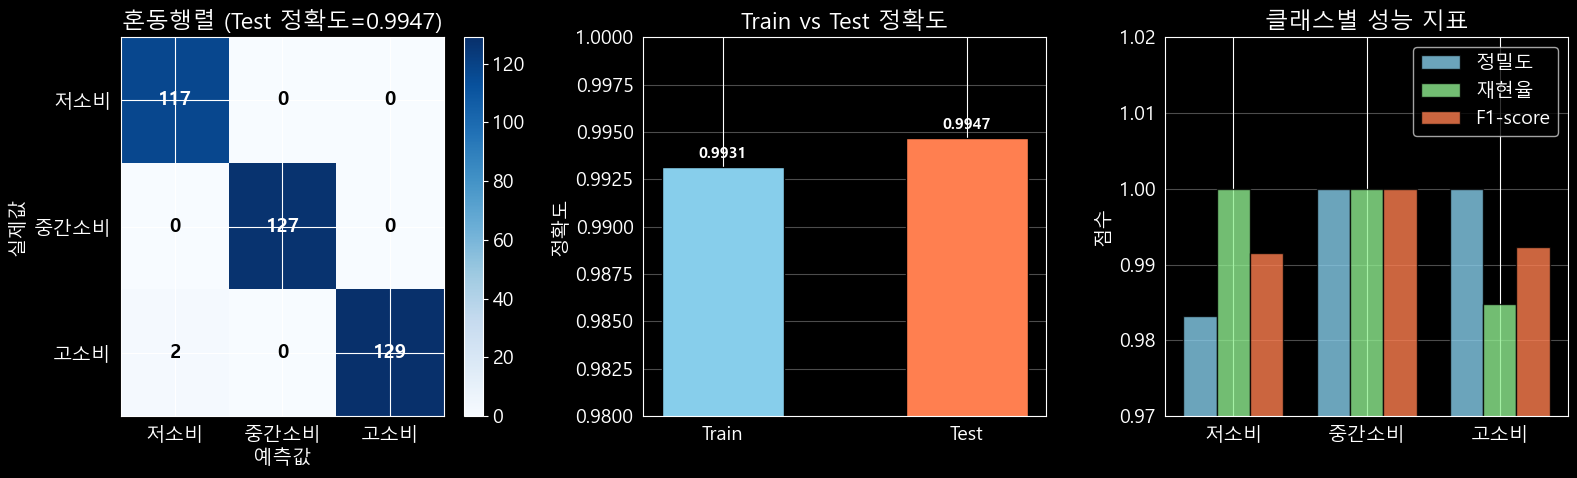

그래프 저장 완료: output/04_의사결정나무_분류분석.png


In [23]:
# 분류 모델 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. 혼동행렬 히트맵
cm = confusion_matrix(y_test_c, y_test_pred_c)
class_labels = ['저소비', '중간소비', '고소비']
im = axes[0].imshow(cm, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)
axes[0].set_xlabel('예측값')
axes[0].set_ylabel('실제값')
axes[0].set_title(f'혼동행렬 (Test 정확도={test_accuracy:.4f})')

# 혼동행렬에 숫자 표시
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                       color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[0])

# 2. Train vs Test 정확도 비교
accuracies = [train_accuracy, test_accuracy]
axes[1].bar(['Train', 'Test'], accuracies, color=['skyblue', 'coral'], edgecolor='black', width=0.5)
axes[1].set_ylabel('정확도')
axes[1].set_ylim([0.98, 1.0])
axes[1].set_title('Train vs Test 정확도')
axes[1].grid(True, alpha=0.3, axis='y')

# 각 바에 값 표시
for i, (label, acc) in enumerate(zip(['Train', 'Test'], accuracies)):
    axes[1].text(i, acc + 0.0005, f'{acc:.4f}', ha='center', fontweight='bold', fontsize=11)

# 3. 클래스별 정밀도, 재현율, F1-score
from sklearn.metrics import precision_score, recall_score, f1_score

precision = [precision_score(y_test_c, y_test_pred_c, labels=[0, 1, 2], average=None)[i] for i in range(3)]
recall = [recall_score(y_test_c, y_test_pred_c, labels=[0, 1, 2], average=None)[i] for i in range(3)]
f1 = [f1_score(y_test_c, y_test_pred_c, labels=[0, 1, 2], average=None)[i] for i in range(3)]

x = np.arange(3)
width = 0.25

axes[2].bar(x - width, precision, width, label='정밀도', alpha=0.8, color='skyblue', edgecolor='black')
axes[2].bar(x, recall, width, label='재현율', alpha=0.8, color='lightgreen', edgecolor='black')
axes[2].bar(x + width, f1, width, label='F1-score', alpha=0.8, color='coral', edgecolor='black')

axes[2].set_ylabel('점수')
axes[2].set_ylim([0.97, 1.02])
axes[2].set_xticks(x)
axes[2].set_xticklabels(class_labels)
axes[2].set_title('클래스별 성능 지표')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/04_의사결정나무_분류분석.png', dpi=100, bbox_inches='tight')
plt.show()

print("그래프 저장 완료: output/04_의사결정나무_분류분석.png")

In [24]:
## 최종 요약

In [25]:
print("="*70)
print("의사결정나무 머신러닝 분석 최종 요약")
print("="*70)

print("\n" + "="*70)
print("[ OPTION A: 의사결정나무 회귀 분석 ]")
print("="*70)
print(f"\n 목표: 카드 소비액 정확한 수치 예측")
print(f"\n[성능]")
print(f"  Test R² 점수:    0.9951 (99.51% 설명력)")
print(f"  MAE:            451원")
print(f"  RMSE:           903원")
print(f"  오차율:         8.64%")
print(f"  교차검증 R²:     0.9935")

print(f"\n[핵심 발견]")
print(f"  - 할인점외 소비가 95.79% 영향")
print(f"  - 나머지 특징들은 거의 영향 없음")
print(f"  - 과적합 없음 (Train-Test 차이 0.27%)")

print("\n" + "="*70)
print("[ OPTION B: 의사결정나무 분류 분석 ]")
print("="*70)
print(f"\n 목표: 지역을 고소비/중간소비/저소비로 분류")
print(f"\n[분류 기준]")
print(f"  저소비:  {q33:,.0f}원 이하")
print(f"  중간소비: {q33:,.0f}원 ~ {q67:,.0f}원")
print(f"  고소비:  {q67:,.0f}원 이상")

print(f"\n[성능]")
print(f"  Test 정확도:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Train 정확도:    {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  교차검증 정확도: {cv_scores_c.mean():.4f}")

print(f"\n[클래스별 성능]")
class_names_list = ['저소비', '중간소비', '고소비']
for i, class_name in enumerate(class_names_list):
    p = precision_score(y_test_c, y_test_pred_c, labels=[i], average=None)[0]
    r = recall_score(y_test_c, y_test_pred_c, labels=[i], average=None)[0]
    f = f1_score(y_test_c, y_test_pred_c, labels=[i], average=None)[0]
    print(f"  {class_name:6s}: 정밀도={p:.4f}, 재현율={r:.4f}, F1={f:.4f}")

print(f"\n[혼동행렬]")
print(cm)
print(f"  행=실제값, 열=예측값 (저소비, 중간소비, 고소비 순서)")

print(f"\n[특징 중요도]")
top_n = 3
for i, (idx, row) in enumerate(feature_importance_c.head(top_n).iterrows(), 1):
    print(f"  {i}. {row['Feature']:15s}: {row['Importance']*100:6.2f}%")

print("\n" + "="*70)
print("✓ 의사결정나무 회귀 + 분류 분석 완료")
print("="*70)

print(f"\n 생성된 결과 이미지:")
print(f"  - output/02_의사결정나무_회귀분석.png")
print(f"  - output/03_하이퍼파라미터튜닝.png")
print(f"  - output/04_의사결정나무_분류분석.png")

의사결정나무 머신러닝 분석 최종 요약

[ OPTION A: 의사결정나무 회귀 분석 ]

📊 목표: 카드 소비액 정확한 수치 예측

[성능]
  Test R² 점수:    0.9951 (99.51% 설명력)
  MAE:            451원
  RMSE:           903원
  오차율:         8.64%
  교차검증 R²:     0.9935

[핵심 발견]
  - 할인점외 소비가 95.79% 영향
  - 나머지 특징들은 거의 영향 없음
  - 과적합 없음 (Train-Test 차이 0.27%)

[ OPTION B: 의사결정나무 분류 분석 ]

🎯 목표: 지역을 고소비/중간소비/저소비로 분류

[분류 기준]
  저소비:  1,638원 이하
  중간소비: 1,638원 ~ 11,875원
  고소비:  11,875원 이상

[성능]
  Test 정확도:     0.9947 (99.47%)
  Train 정확도:    0.9931 (99.31%)
  교차검증 정확도: 0.9880

[클래스별 성능]
  저소비   : 정밀도=0.9832, 재현율=1.0000, F1=0.9915
  중간소비  : 정밀도=1.0000, 재현율=1.0000, F1=1.0000
  고소비   : 정밀도=1.0000, 재현율=0.9847, F1=0.9923

[혼동행렬]
[[117   0   0]
 [  0 127   0]
 [  2   0 129]]
  행=실제값, 열=예측값 (저소비, 중간소비, 고소비 순서)

[특징 중요도]
  1. 할인점외           :  99.37%
  2. 소형유통           :   0.34%
  3. 백화점            :   0.22%

✓ 의사결정나무 회귀 + 분류 분석 완료

📈 생성된 결과 이미지:
  - output/02_의사결정나무_회귀분석.png
  - output/03_하이퍼파라미터튜닝.png
  - output/04_의사결정나무_분류분석.png
